In [6]:
# CARREGAR ARQUIVO PICKLE - DADOS + SUBSTANTIVOS
# Carrega as princiapais variáveis já processadas, útil para economizar tempo
import pickle

caminho_arquivo = 'dados_substantivos.pickle'
with open(caminho_arquivo, 'rb') as arquivo_entrada:
   transcricoes_dados_dict, transcricoes_lista_por_sentencas, transcricoes_lista_por_texto_completo,                 transcricoes_string_unica, substantivos_mais_usados = pickle.load(arquivo_entrada)
del arquivo_entrada, caminho_arquivo


In [18]:
import spacy
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from networkx.algorithms import community

def analise_similitude_iramuteq(lista_uces, classes_alvo={"NOUN", "ADJ", "VERB", "PROPN"}, min_freq=2):
    """
    Simula a Análise de Similitude do IRAMUTEQ extraindo o grafo de coocorrência e a Árvore Máxima.
    """
    print("1. Processamento Lexicográfico...")
    nlp = spacy.load("pt_core_news_lg", disable=["parser", "ner"])

    uces_processadas = []
    for doc in nlp.pipe(lista_uces, batch_size=50):
        lema_uce = [
            token.lemma_.lower() for token in doc
            if token.pos_ in classes_alvo and token.is_alpha
        ]
        uces_processadas.append(" ".join(lema_uce))

    print("2. Construção da Matriz de Coocorrência...")
    # Vetorização binária (presença/ausência no segmento)
    vectorizer = CountVectorizer(binary=True, min_df=min_freq)
    X = vectorizer.fit_transform(uces_processadas)
    vocabulario = vectorizer.get_feature_names_out()

    # Álgebra Linear: Matriz de Coocorrência C = X^T * X
    matriz_coocorrencia = (X.T * X).toarray()

    # Zera a diagonal principal para não criar auto-arestas (loops no grafo)
    np.fill_diagonal(matriz_coocorrencia, 0)

    df_adjacencia = pd.DataFrame(matriz_coocorrencia, index=vocabulario, columns=vocabulario)

    print("3. Construção do Grafo e Extração da Árvore Máxima...")
    # Cria o grafo a partir da matriz de adjacência
    G_completo = nx.from_pandas_adjacency(df_adjacencia)

    # Remove arestas com peso 0
    arestas_vazias = [(u, v) for u, v, d in G_completo.edges(data=True) if d['weight'] == 0]
    G_completo.remove_edges_from(arestas_vazias)

    # Calcula a Árvore Máxima (Maximum Spanning Tree)
    # O NetworkX extrai a Maximum Spanning Tree invertendo a lógica da Minimum Spanning Tree
    arvore_maxima = nx.maximum_spanning_tree(G_completo, algorithm='kruskal')

    return G_completo, arvore_maxima, vocabulario

def plotar_arvore_maxima(arvore_maxima):
    """
    Renderiza a árvore máxima aplicando detecção de comunidades para colorir
    os galhos e o algoritmo Kamada-Kawai para esticar a hierarquia.
    """
    plt.figure(figsize=(36, 36), facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')

    print("Calculando layout e hierarquia espacial (Kamada-Kawai)...")
    # 1. LAYOUT DE DISTÂNCIA: Kamada-Kawai estica a árvore e separa os ramos,
    # evitando o "efeito globo" do spring_layout.
    pos = nx.kamada_kawai_layout(arvore_maxima)

    print("Calculando comunidades para colorização dos galhos...")
    # 2. COMUNIDADES: Identifica as sub-redes (galhos) para pintar da mesma cor
    comunidades = list(community.greedy_modularity_communities(arvore_maxima))
    cores_base = list(mcolors.TABLEAU_COLORS.values()) # Paleta de cores nítidas

    # Mapeia cada nó para a cor da sua respectiva comunidade
    mapa_cores_nos = []
    for node in arvore_maxima.nodes():
        for i, com in enumerate(comunidades):
            if node in com:
                mapa_cores_nos.append(cores_base[i % len(cores_base)])
                break

    # 3. ESCALONAMENTO DE HIERARQUIA: Amplifica a diferença entre o centro e as pontas
    graus = dict(arvore_maxima.degree(weight='weight'))

    # Elevar a 1.5 aumenta drasticamente o tamanho dos hubs centrais em relação às folhas
    tamanho_nos = [ (v ** 1.5) * 100 for v in graus.values()]

    # Calcula a espessura das linhas baseada na força da coocorrência
    pesos = [arvore_maxima[u][v]['weight'] for u, v in arvore_maxima.edges()]
    espessura_arestas = [ (p / max(pesos)) * 8 for p in pesos] if pesos else 1

    # 4. PLOTAGEM DO GRAFO
    nx.draw_networkx_edges(arvore_maxima, pos, width=espessura_arestas, edge_color='lightgray', alpha=0.7)
    nx.draw_networkx_nodes(arvore_maxima, pos, node_size=tamanho_nos, node_color=mapa_cores_nos,
                           alpha=0.9, edgecolors='white', linewidths=2)

    # 5. LEGIBILIDADE DOS TEXTOS
    # Adiciona as palavras com um leve fundo branco translúcido para não se misturarem com as linhas
    labels = nx.draw_networkx_labels(arvore_maxima, pos, font_size=12, font_weight="bold")
    for t in labels.values():
        t.set_bbox(dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

    plt.title("Análise de Similitude (Árvore Máxima e Comunidades)", fontsize=18)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

1. Processamento Lexicográfico...
2. Construção da Matriz de Coocorrência...
3. Construção do Grafo e Extração da Árvore Máxima...

Grafo Completo: 180 nós, 1998 arestas.
Árvore Máxima: 180 nós, 177 arestas.
Calculando layout e hierarquia espacial (Kamada-Kawai)...
Calculando comunidades para colorização dos galhos...


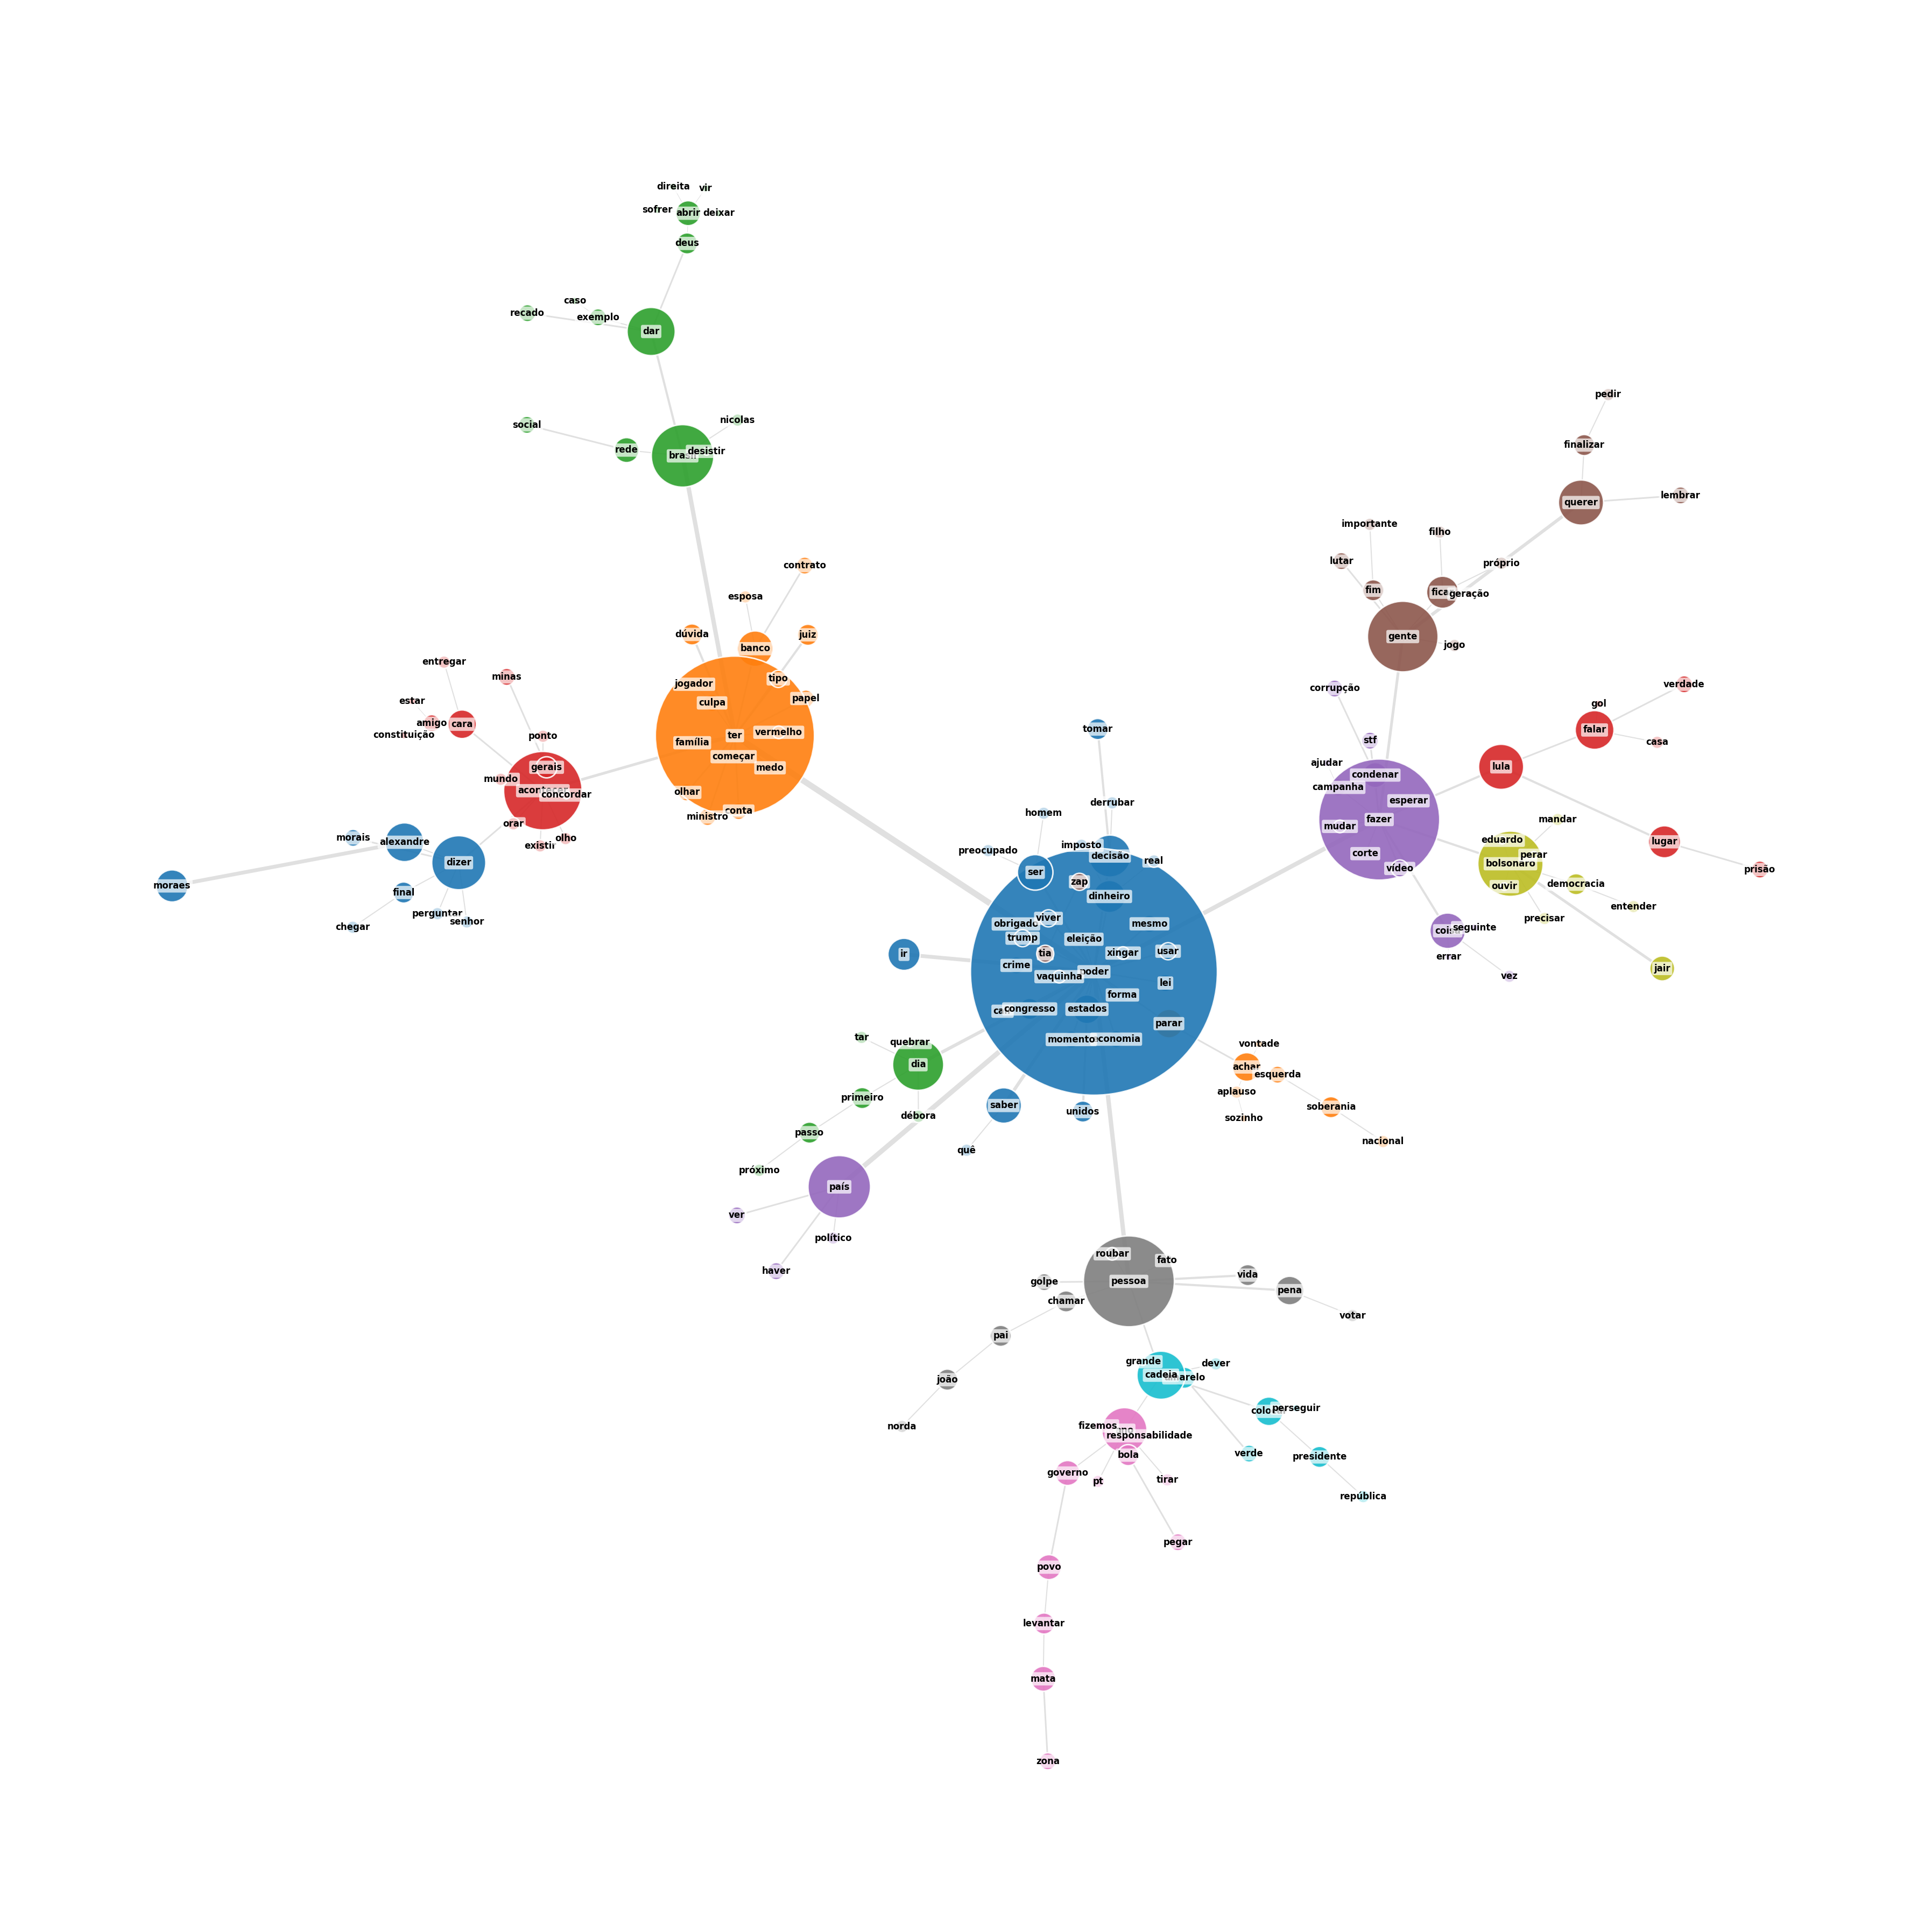

In [19]:

# ==============================================================================
# EXECUÇÃO DE TESTE
# ==============================================================================
if __name__ == "__main__":
    corpus_teste = [
        "O governo aprovou a reforma tributária no congresso ontem.",
        "A oposição criticou o governo e a reforma no congresso.",
        "A economia exige a aprovação da reforma urgente.",
        "O ministro da economia defendeu o governo durante a sessão.",
        "O congresso votou a favor da reforma tributária proposta pelo governo.",
        "A inflação afeta a economia e preocupa o governo."
    ]

    # Executa a função definindo min_freq=1 para o pequeno corpus de teste
    grafo_total, arvore, vocab = analise_similitude_iramuteq(transcricoes_lista_por_sentencas[1:365], min_freq=3)

    print(f"\nGrafo Completo: {grafo_total.number_of_nodes()} nós, {grafo_total.number_of_edges()} arestas.")
    print(f"Árvore Máxima: {arvore.number_of_nodes()} nós, {arvore.number_of_edges()} arestas.")

    plotar_arvore_maxima(arvore)